# Structural characterization of networks

In this notebook, we will learn the functions needed to characterize both the microscopic and the macroscopic structure of networks. We will use the network of collaborations represented in the previous notebook

2. [Macroscopic characterization of networks](#section2)

## 1. Codes to set up the notebook for the simulation

### Code to grant access to the Google Drive folder

This command will be recurrent in all the notebooks and will allow us to set the working directory in our Google drive folder

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/CN_MHEDAS/Notebooks")

ModuleNotFoundError: No module named 'google'

### Code to import the needed modules/packages to run the notebook

In [1]:
import pandas as pd ## dataframes
import numpy as np ## Mathematical operations
import matplotlib.pyplot as plt ## Representation
from matplotlib import rcParams
from matplotlib import colors
import random as random
import networkx as nx ## Network tools

<a name='section2'></a>

## 2. Macroscopic characterization of networks

<a id='section2'></a>

We've found the most central node in the network, but often we want to summarize information about the centrality of all nodes. For example, in addition to the maxmimum degree, we often want the mean and median degree in a network.

The first step in summarizing this information is to get a sequence of all of the centrality values in the graph. We don't care about the node names anymore, we just want a sequence of numbers. We can start with the example of degree:

### Connected components

There might be more than one connected component in networks. Typically, there is a giant component, encompassing most of the nodes in the network, and different small components formed by small subgraphs.

The network we'll analyze is the network of recombinant genes from the human malaria parasite Plasmodium falciparum. You can find more detailed data on this network here: https://networks.skewed.de/net/malaria_genes (Dataset) and https://doi.org/10.1371/journal.pcbi.1003268 (Associated publication). We'll restrict the analysis to the highly variable region HVR6

In [2]:
### Code to read the network
nodes_df=pd.read_csv('../Datasets/p_falciparum_nodes.csv') ### this .csv file contains metadata about the nodes of the network
edges_df=pd.read_csv('../Datasets/p_falciparum_edges.csv') ### this .csv file contains the list of edges of the network

In [3]:
nodes_df.rename(columns={'# index':'index'},inplace=True) ### rename the column to avoid problems
edges_df.rename(columns={'# source':'source'},inplace=True) ### rename the column to avoid problems

In [4]:
nodes_position=dict(zip(nodes_df['index'], nodes_df[' _pos'])) ## create a dictionary with the position of the nodes for the input of networkx
G=nx.from_pandas_edgelist(edges_df,source='source',target=' target') ## create the network

In [5]:
for node in nodes_position.keys():
    nodes_position[node]=[float(nodes_position[node].split(',')[0].split('[')[1]),float(nodes_position[node].split(',')[1].split(']')[0])] ## set the x and y position of the nodes from the previous strings


In [6]:
nodes_position[0][1] ## check whether the value is correct

-5.18663734

Let us represent the network

(np.float64(-2.9283842841),
 np.float64(33.4952443441),
 np.float64(-35.452548666949994),
 np.float64(-0.7545068830500001))

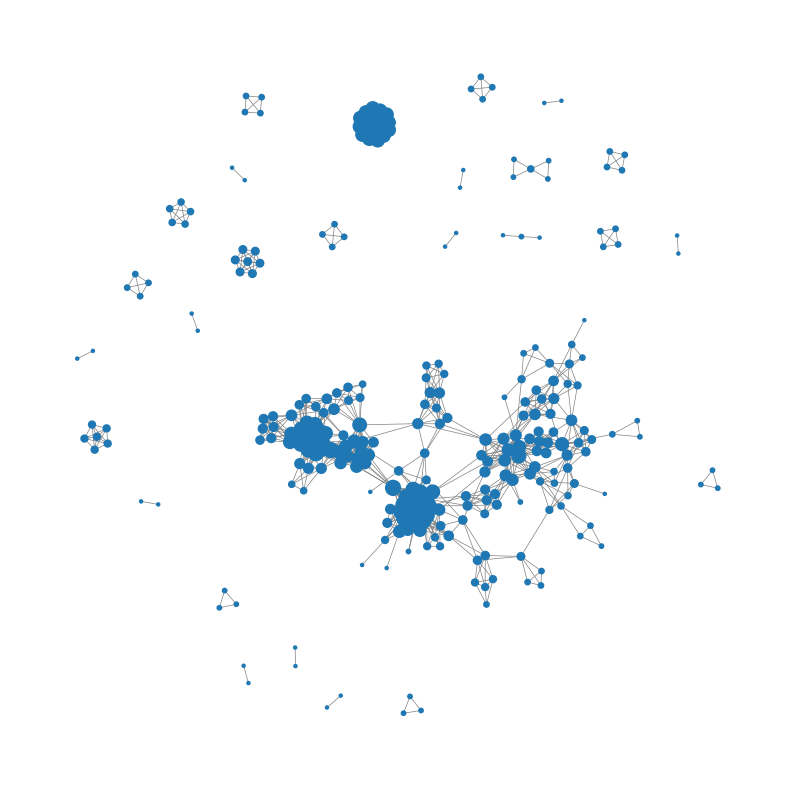

In [7]:
### Represent the network

fig,ax=plt.subplots(1,1,figsize=(10,10))
size_nodes=[5*G.degree(node) for node in G.nodes()]
nx.draw_networkx(G,pos=nodes_position,with_labels=False,node_size=size_nodes,width=0.5,edge_color='grey')
ax.axis('off')

Some of the centrality indicatoris do not work for disconnected networks

In [8]:
nx.eigenvector_centrality(G)

PowerIterationFailedConvergence: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')

Let us get the different components of the network. `nx.connected_components` returns a list containing the different components of the network. In turn, each item of this list encodes the set of nodes belonging to this component

In [9]:
connected_components=list(nx.connected_components(G))

In [10]:
len(connected_components)

27

We can sort the components according to their size

In [11]:
connected_components=sorted(nx.connected_components(G),key=len,reverse=True)

Let us focus on one specific component, for instance, the largest connected component

In [18]:
lcc=max(nx.connected_components(G),key=len) ## One option
lcc=connected_components[0] ### If you want to select the second largest component, just use [1] etc.
G_lcc=G.subgraph(lcc) ### We keep the subgraph of the network linking the nodes in the largest connected component

(np.float64(6.9461980062),
 np.float64(28.550880573800004),
 np.float64(-28.8875493146),
 np.float64(-13.3862870854))

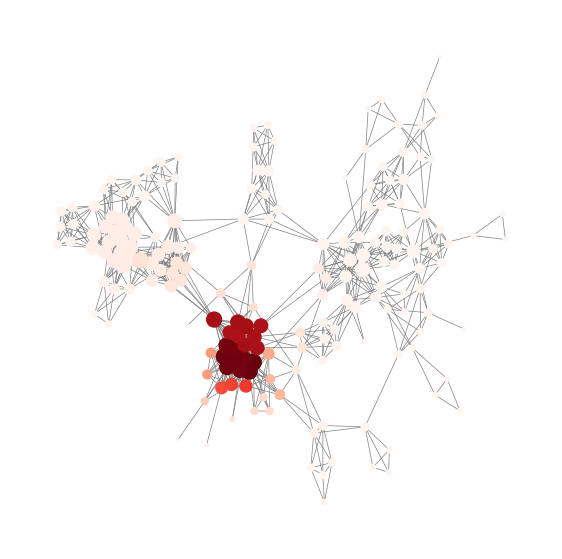

In [19]:
fig,ax=plt.subplots(1,1,figsize=(7,7))
pos_lcc={node:nodes_position[node] for node in G_lcc}
size_nodes=[5*G_lcc.degree(node) for node in G_lcc.nodes()]
eigenvector_centralities=nx.eigenvector_centrality(G_lcc)
color_nodes=[eigenvector_centralities[node] for node in G_lcc.nodes()] ### We set the color according to eigenvector centrality

nx.draw_networkx(G_lcc,pos=pos_lcc,with_labels=False,node_size=size_nodes,node_color=color_nodes,width=0.5,edge_color='grey',cmap='Reds')
ax.axis('off')

### Assortativity

We now move to understand what assortativity quantifies. To do it, we are considering a network in which there is a fixed number of edges which were conveniently reshuffled to set a given value of the network assortativity.

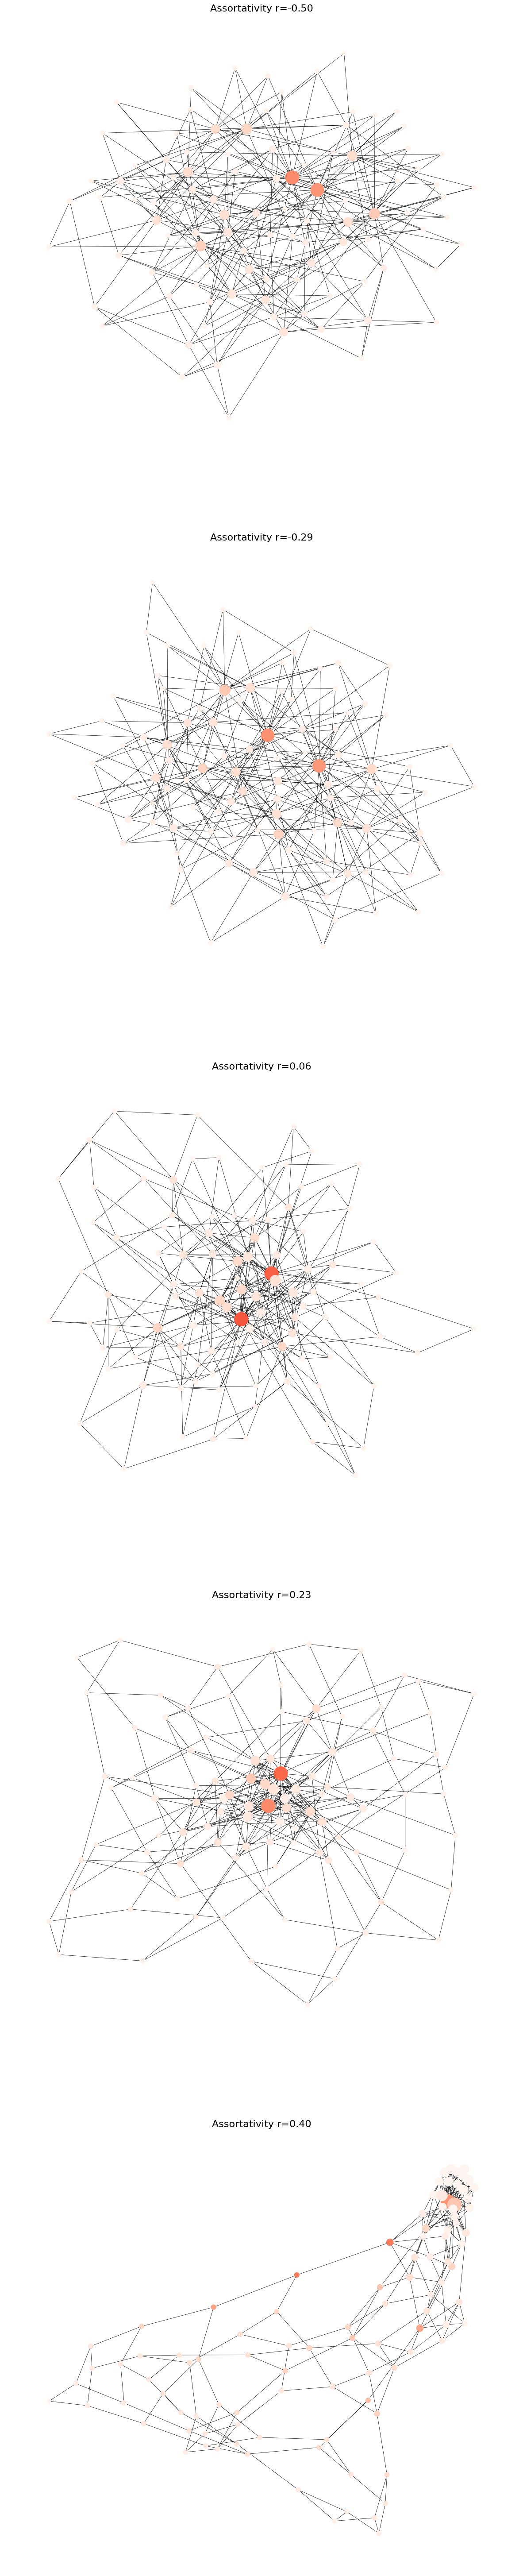

In [20]:
assortativity_values=[-0.50,-0.29,0.06,0.23,0.40]
fig,ax=plt.subplots(5,1,figsize=(15,75))
count_plot=0
for assortativity in assortativity_values:
    G=nx.read_edgelist('../Datasets/BA100assor=%.2lf.txt'%assortativity)
    G=nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    
    ## Get the largest connected component
    lcc = max(nx.connected_components(G), key=len)
    G=G.subgraph(lcc)

    ##Set positions
    positions=nx.kamada_kawai_layout(G)


    #positions=nx.spring_layout(G,k=10)
    
    nodes_sizes=[20*G.degree(node) for node in G.nodes()]
    betweenness_centralities=nx.betweenness_centrality(G)
    nodes_color=[betweenness_centralities[node] for node in G.nodes()]
    nx.draw_networkx(G,node_size=nodes_sizes,node_color=nodes_color,width=0.5,ax=ax[count_plot],with_labels=False,cmap='Reds',vmin=0,vmax=.4)
    ax[count_plot].axis('off')
    ax[count_plot].set_title('Assortativity r=%.2lf'%assortativity,fontsize=16)
    count_plot+=1



### Degree_distribution

Let's come back to the network of collaborations

In [21]:
from scipy.io import mmread
import networkx as nx
a = mmread('../Datasets/ca-netscience.mtx')
G = nx.Graph(a)

We get the degree sequence encoding the degree of each node

In [22]:
degree_sequence = [G.degree(n) for n in G.nodes]

To get the mean and median of this sequence, we can use Python's built-in `statistics` module:

In [23]:
import statistics

print('Mean degree:', statistics.mean(degree_sequence))
print('Median degree:', statistics.median(degree_sequence))

Mean degree: 4.823218997361478
Median degree: 4


For other measures of centrality, which are calculated for the whole network at once and return a dict, we can use the dict's `.values()`.

In [24]:
betweenness = nx.centrality.betweenness_centrality(G)
betweenness_sequence = list(betweenness.values())

print('Mean betweenness:', statistics.mean(betweenness_sequence))
print('Median betweenness:', statistics.median(betweenness_sequence))

Mean betweenness: 0.013373653442800924
Median betweenness: 0.0


### Plotting the distribution

We can graphically represent the sequence of centrality values by using a *histogram*. In its basic form, a histogram plots the degree values on the x-axis, and the number of nodes having that degree on the y-axis. To do this counting, we can make use of Python's `collections.Counter`.

In [25]:
from collections import Counter

degree_counts = Counter(degree_sequence)
degree_counts

Counter({2: 74,
         3: 72,
         4: 62,
         6: 36,
         5: 33,
         1: 27,
         7: 20,
         8: 12,
         9: 9,
         12: 8,
         10: 6,
         11: 5,
         14: 4,
         15: 3,
         27: 2,
         34: 1,
         16: 1,
         21: 1,
         19: 1,
         18: 1,
         17: 1})

The `Counter` object returned is like a dict, pairing the item counted with the number of times it showed up in the sequence.

On this basic histogram plot, we want an x-value for every integer between the minimum and maximum degree in the sequence, inclusive. Note that `degree_counts.keys()` gives us every distinct value seen in the degree sequence. Also note that we need the +1 in the `range` below because we want to include the right endpoint.

In [26]:
min_degree, max_degree = min(degree_counts.keys()), max(degree_counts.keys())

degree = list(range(min_degree, max_degree + 1))

In [27]:
degree

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34]

Our y-values are then the number of times we counted each x-value in the degree sequence. We can make use of the `.get` method with a default value in order to count 0 for degree values that don't show up in the sequence. For example, notice that 32 does not show up in `degree_counts` above, so `degree_counts.get(32, 0)` will give us 0.

In [28]:
degree_count = [degree_counts.get(x, 0) for x in degree]

To do the plotting, we use Matplotlib's `pyplot` module.

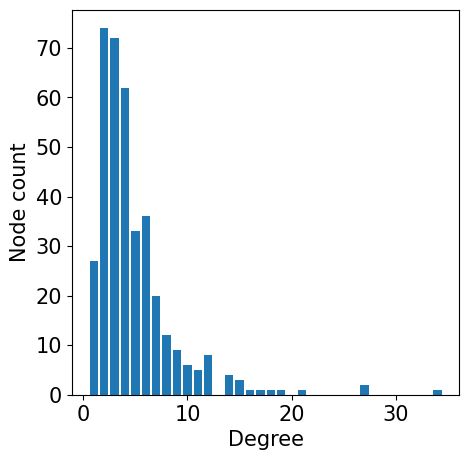

In [29]:
fig,ax=plt.subplots(1,1,figsize=(5,5))


ax.bar(degree, degree_count)
ax.set_ylabel('Node count',fontsize=15)
ax.set_xlabel('Degree',fontsize=15)
ax.tick_params(which='major',axis='both',labelsize=15)
# nodes with degree $k$

### Histogram binning

When there are more x-values than you can comfortably display, or when your centrality measure is not discrete, as in the case of betweenness centrality, we can make use of histogram "binning." This just defines a sequence of disjoint intervals called *bins*, and counts the number of values that fall into each such bin. In the simplest of cases, we can just tell Pyplot's `hist` function how many bins we want and it will do the binning for us.

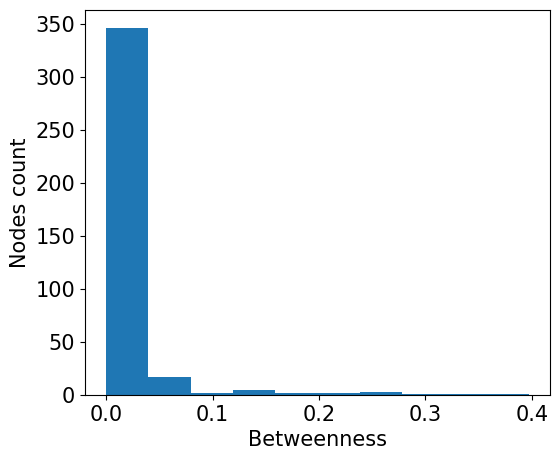

In [30]:
fig,ax=plt.subplots(1,1,figsize=(6,5))

counts, bins, patches = plt.hist(betweenness_sequence, bins=10)
ax.set_ylabel('Nodes count',fontsize=15)
ax.set_xlabel('Betweenness',fontsize=15)
ax.tick_params(which='major',axis='both',labelsize=15)

We can investigate the returned `bins` and `counts` if we want:

In [31]:
bins

array([0.        , 0.03971842, 0.07943684, 0.11915525, 0.15887367,
       0.19859209, 0.23831051, 0.27802893, 0.31774735, 0.35746576,
       0.39718418])

In [32]:
counts

array([346.,  17.,   2.,   4.,   2.,   2.,   3.,   1.,   1.,   1.])

From these, we can see that there are 115 values between 0 and 0.0194006, 13 values between 0.194006 and 0.3880121, etc.

### Fitting a power-law degree distribution

Let us study a network whose degree distribution obeys $P(k)= Ck^{-\gamma}$

In [33]:
G=nx.read_edgelist('../Datasets/synthetic_network.edges')
print('Number of nodes is %d'%G.number_of_nodes())
print('Number of edges is %d'%G.number_of_edges())

Number of nodes is 10000
Number of edges is 39984


The network is much larger than the ones we have dealt with so far. Network visualization in this case might not be helpful due to the amount of nodes/edges

Let's represent the degree distribution to characterize the macroscopic structure of the network

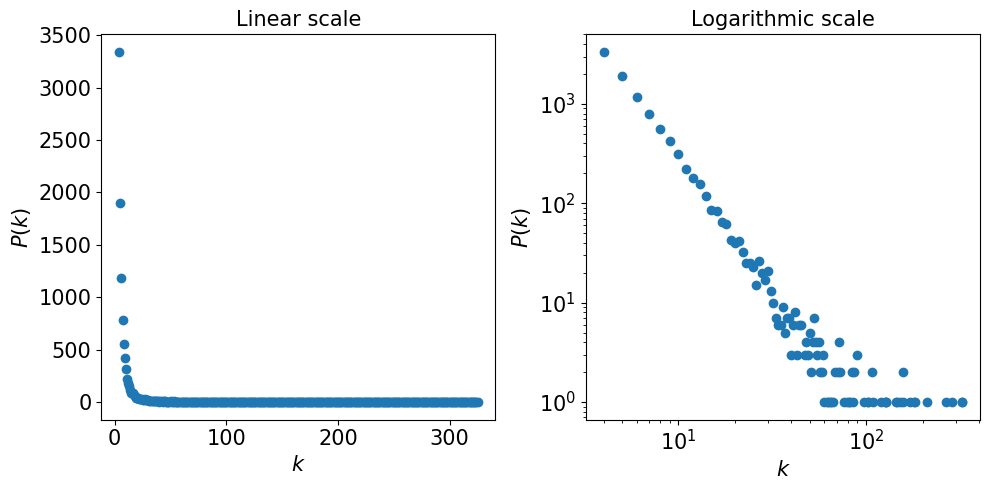

In [34]:

fig,ax=plt.subplots(1,2,figsize=(10,5))
degree_sequence=[G.degree(node) for node in G.nodes()]
from collections import Counter

degree_counts = Counter(degree_sequence)
min_degree=min(degree_sequence)
max_degree=max(degree_sequence)

degree = list(range(min_degree, max_degree + 1))
degree_count = [degree_counts.get(x, 0) for x in degree]


ax[0].scatter(degree, degree_count,label='data')
ax[1].scatter(degree, degree_count,label='data')

ax[0].set_xlabel('$k$',fontsize=15)  ### Set label of the axis
ax[0].set_ylabel('$P(k)$',fontsize=15)

ax[1].set_xlabel('$k$',fontsize=15) ### Set label of the axis
ax[1].set_ylabel('$P(k)$',fontsize=15) 

ax[1].set_yscale('log') ### Set logarithmic scale
ax[1].set_xscale('log')

ax[0].tick_params(which='major',axis='both',labelsize=15) ### Size labels ticks
ax[1].tick_params(which='major',axis='both',labelsize=15)


ax[0].set_title('Linear scale',fontsize=15)
ax[1].set_title('Logarithmic scale',fontsize=15)
fig.tight_layout()



#### Fit using P(k)

There seems to be some power-law behavior. Let's try to fit it by assuming that:

\begin{equation*}
\log(P(k)) = m \log(k) + b
\end{equation*}

In [37]:
log_degree=[np.log(degree[i]) for i in range(len(degree)) if degree_count[i]!=0] ### Use the degree classes with at least one node
log_degree_count=[np.log(degree_count[i]) for i in range(len(degree_count)) if degree_count[i]!=0]


m,b = np.polyfit(log_degree, log_degree_count, 1) ## Fit log(P(k)) to a line with slope m and intercept b

From the theoretical expression, we know that $\gamma=-m$ and $C=e^b$.

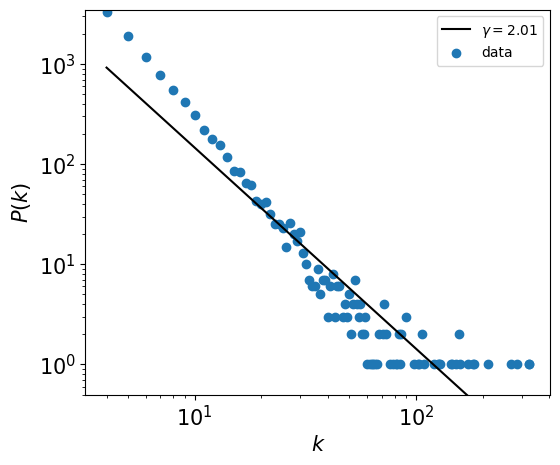

In [38]:
theoretical=[np.exp(b)*k**m for k in degree] ### obtain the theoretical values from the fitted parameters


fig,ax=plt.subplots(1,1,figsize=(6,5))

ax.plot(degree, theoretical,color='black',label=r'$\gamma=%.2lf$'%(-m))
ax.scatter(degree, degree_count,label='data')
ax.set_ylim(0.5,)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlabel('$k$',fontsize=15)
ax.set_ylabel('$P(k)$',fontsize=15)

ax.tick_params(which='major',axis='both',labelsize=15)
ax.legend()

Fit is very poor... As explained in the lecture, the CCDF is a better option to reduce the noise of the degree distribution, especially at the tail

#### Fit using CDF

/var/folders/y_/1f6tyxqn3hd98mt_8yc4vp0r0000gn/T/ipykernel_31936/3527016897.py:18: RuntimeWarning: divide by zero encountered in log
  log_ccdf_fit=np.log(ccdf)[:-1]


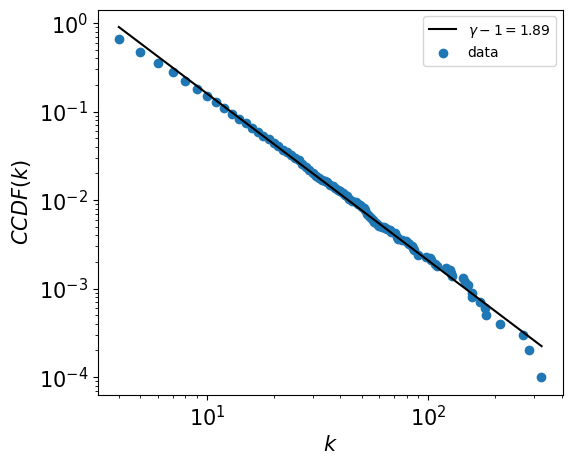

In [39]:
degree_sequence=[G.degree(node) for node in G.nodes()]
from collections import Counter

degree_counts = Counter(degree_sequence)
min_degree=min(degree_sequence)
max_degree=max(degree_sequence)

degree = list(range(min_degree, max_degree + 1))
degree_count = [degree_counts.get(k, 0) for k in degree]

degree=[degree[i] for i in range(len(degree)) if degree_count[i]!=0]
degree_count=[degree_count[i] for i in range(len(degree_count)) if degree_count[i]!=0]

cdf=np.cumsum(degree_count)/G.number_of_nodes() ### Get the cumulative sum of the distribution (without normalized)
ccdf=np.ones(len(cdf))-cdf #### Get the CCDF 

log_degree_fit=[np.log(degree[i]) for i in range(len(degree))][:-1] ## Last point should be excluded as 0 in logarithmic scale is not finite
log_ccdf_fit=np.log(ccdf)[:-1]

m,b = np.polyfit(log_degree_fit, log_ccdf_fit, 1) 

theoretical=[np.exp(b)*k**m for k in degree]

fig,ax=plt.subplots(1,1,figsize=(6,5))

ax.plot(degree, theoretical,color='black',label=r'$\gamma-1=%.2f$'%(-m))
ax.scatter(degree, ccdf,label='data')


ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlabel('$k$',fontsize=15)
ax.set_ylabel('$CCDF(k)$',fontsize=15)

ax.tick_params(which='major',axis='both',labelsize=15)

ax.legend()

The goodness of the fit is considerably better when using the CCDF. In addition, the fit yields an exponent $\gamma\simeq 2.89$, close to actual exponent of the power-law distribution ($\gamma=3$).

#### Warning on the use of histograms to fit the degree distributions

The problem comes when using the histogram bins and the counts to fit the histogram to a power-law function in order to obtain an exponent. Let's illustrate it with linear binning, yet we know that logarithmic binning is more recommendable

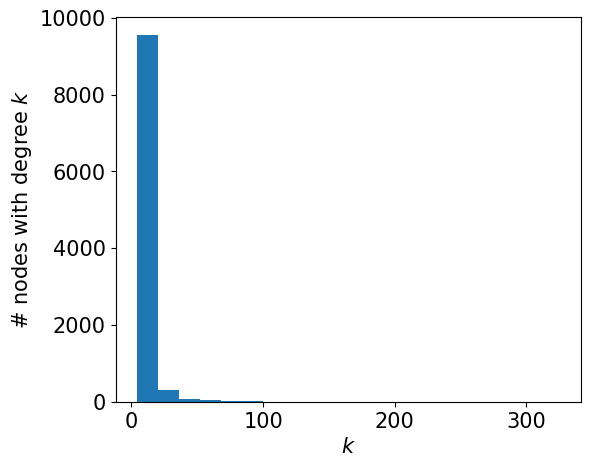

In [41]:
fig,ax=plt.subplots(1,1,figsize=(6,5))
degree_sequence=[G.degree(node) for node in G.nodes()]
degree_counts, degree, patches = ax.hist(degree_sequence, bins=20)


ax.set_xlabel('$k$',fontsize=15)
ax.set_ylabel('# nodes with degree $k$',fontsize=15)
ax.tick_params(which='major',axis='both',labelsize=15)

In [42]:
m,b = np.polyfit(degree, degree_counts, 1) 

TypeError: expected x and y to have same length

In [43]:
print('There are %d "degree classes" ' %len(degree))
print('There are %d degree count values' %len(degree_counts))

There are 21 "degree classes" 
There are 20 degree count values


In reality, the points in degree reflects the limits of the intervals encoded in each bin of the histogram. To take a degree as a reference for fitting purposes, take the middle point for each bin.

In [44]:
widths=[degree[i+1]-degree[i] for i in range(len(degree)-1)]
degree_fit=[degree[i]+widths[i]/2 for i in range(len(degree)-1)]

Let us represent the histogram again by using the midpoint of each bin

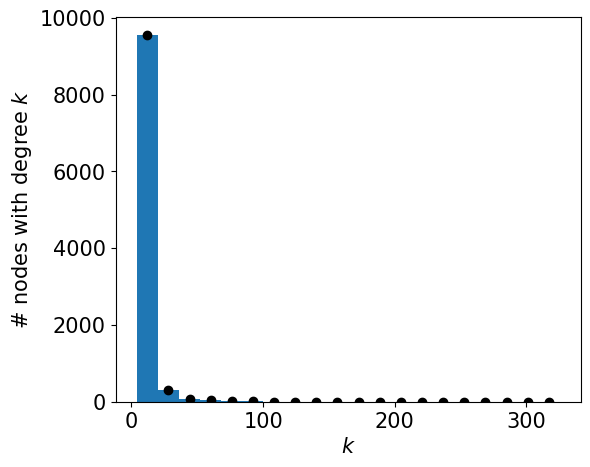

In [45]:
fig,ax=plt.subplots(1,1,figsize=(6,5))

degree_counts, degree, patches = ax.hist(degree_sequence, bins=20,zorder=0)

ax.set_xlabel('$k$',fontsize=15)
ax.set_ylabel('# nodes with degree $k$',fontsize=15)
ax.tick_params(which='major',axis='both',labelsize=15)

ax.scatter(degree_fit,degree_counts,color='black')

In [46]:
m,b = np.polyfit(degree_fit, degree_counts, 1) 

In [47]:
print(m)

-8.820556063054836


Now it works but yields a meaningless result.. as the fit should be done in logarithmic scale. Logarithmic binning is required then (Part of activity A1 duties)

### Real networks

Let us study the degree distribution of the network of tweet exchanged during a major event discussing climate in NYC in March 2014

In [48]:
df=pd.read_csv('../Datasets/NYClimateMarch2014.csv')
G=nx.from_pandas_edgelist(df,source='source',target='target',edge_attr='weight')

In [49]:
df

,source,target,weight
0,176,11665,1
1,176,9797,1
2,176,4045,1
3,176,14001,1
4,176,148,2
...,...,...,...
212888,29333,29332,1
212889,51033,51034,1
212890,90198,90199,1
212891,30032,29668,1


/var/folders/y_/1f6tyxqn3hd98mt_8yc4vp0r0000gn/T/ipykernel_31936/1430736817.py:18: RuntimeWarning: divide by zero encountered in log
  log_ccdf_fit=np.log(ccdf)[:-1]


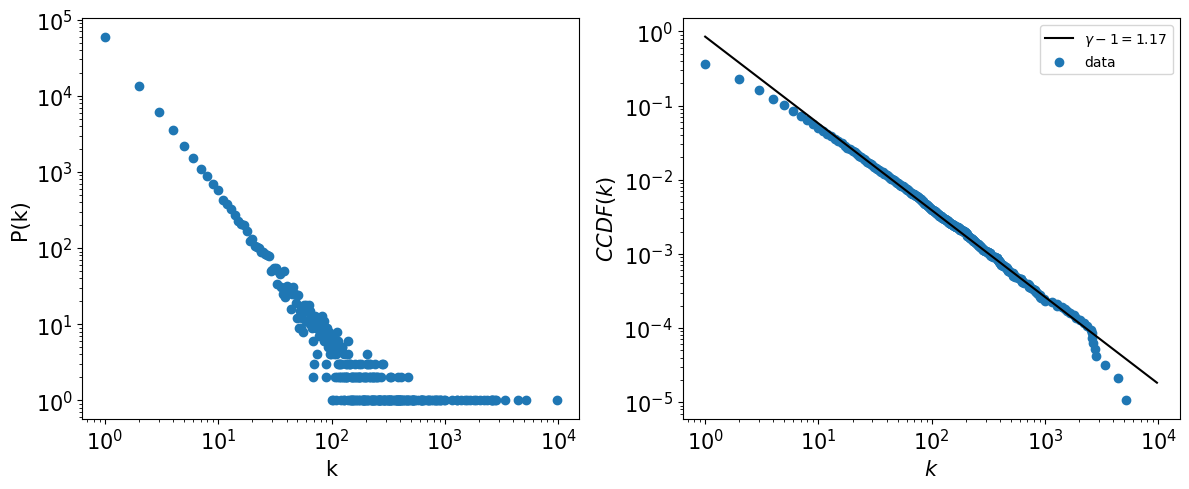

In [52]:
degree_sequence=[G.degree(node) for node in G.nodes()]
from collections import Counter

degree_counts = Counter(degree_sequence)
min_degree=min(degree_sequence)
max_degree=max(degree_sequence)

degree = list(range(min_degree, max_degree + 1))
degree_count = [degree_counts.get(k, 0) for k in degree]

degree=[degree[i] for i in range(len(degree)) if degree_count[i]!=0]
degree_count=[degree_count[i] for i in range(len(degree_count)) if degree_count[i]!=0]

cdf=np.cumsum(degree_count)/G.number_of_nodes() ### Get the cumulative sum of the distribution (without normalized)
ccdf=np.ones(len(cdf))-cdf #### Get the CCDF 

log_degree_fit=[np.log(degree[i]) for i in range(len(degree))][:-1] ## Last point should be excluded as 0 in logarithmic scale is not finite
log_ccdf_fit=np.log(ccdf)[:-1]

m,b = np.polyfit(log_degree_fit, log_ccdf_fit, 1) 

theoretical=[np.exp(b)*k**m for k in degree]

fig,ax=plt.subplots(1,2,figsize=(12,5))


ax[0].scatter(degree,degree_count)
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].set_ylabel('P(k)',fontsize=15)
ax[0].set_xlabel('k',fontsize=15)
ax[0].tick_params(which='major',axis='both',labelsize=15)


ax[1].plot(degree, theoretical,color='black',label=r'$\gamma-1=%.2f$'%(-m))
ax[1].scatter(degree, ccdf,label='data')

ax[1].set_yscale('log')
ax[1].set_xscale('log')

ax[1].set_xlabel('$k$',fontsize=15)
ax[1].set_ylabel('$CCDF(k)$',fontsize=15)

ax[1].tick_params(which='major',axis='both',labelsize=15)

ax[1].legend()

fig.tight_layout()

What's the result when representing the distribution of the strength of each node?

In [53]:
strength_sequence=[round(G.degree(node,weight='weight')) for node in G.nodes()]

/var/folders/y_/1f6tyxqn3hd98mt_8yc4vp0r0000gn/T/ipykernel_31936/1354484124.py:15: RuntimeWarning: divide by zero encountered in log
  log_ccdf_fit=np.log(ccdf)[:-1]


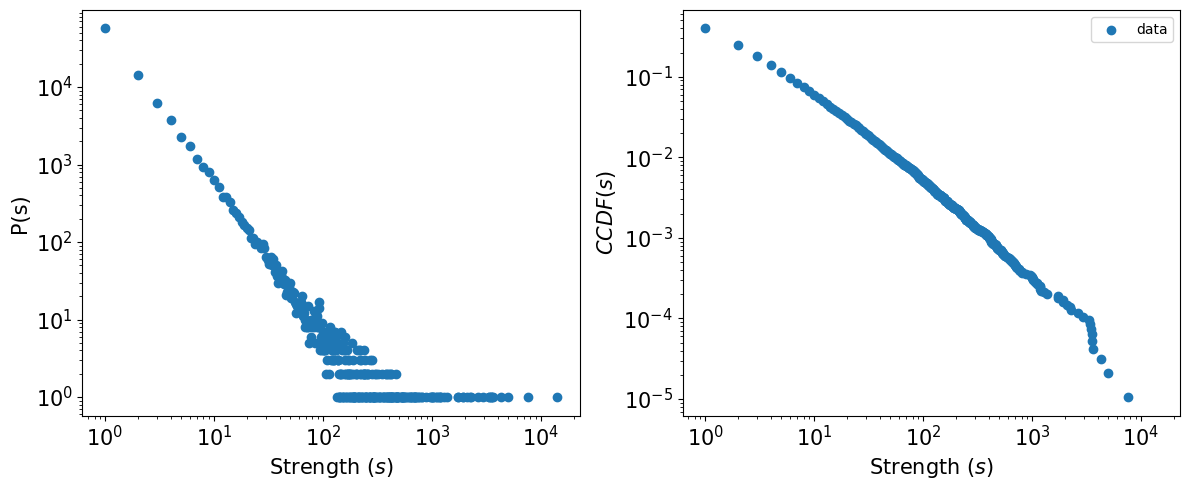

In [54]:
strength_counts = Counter(strength_sequence)
min_strength=min(strength_sequence)
max_strength=max(strength_sequence)

strength = list(range(min_strength, max_strength + 1))
strength_count = [strength_counts.get(k, 0) for k in strength]

strength=[strength[i] for i in range(len(strength)) if strength_count[i]!=0]
strength_count=[strength_count[i] for i in range(len(strength_count)) if strength_count[i]!=0]

cdf=np.cumsum(strength_count)/G.number_of_nodes() ### Get the cumulative sum of the distribution (without normalized)
ccdf=np.ones(len(cdf))-cdf #### Get the CCDF 

log_strength_fit=[np.log(strength[i]) for i in range(len(strength))][:-1] ## Last point should be excluded as 0 in logarithmic scale is not finite
log_ccdf_fit=np.log(ccdf)[:-1]


fig,ax=plt.subplots(1,2,figsize=(12,5))


ax[0].scatter(strength,strength_count)

ax[0].set_yscale('log')
ax[0].set_xscale('log')

ax[0].set_ylabel('P(s)',fontsize=15)
ax[0].set_xlabel('Strength $(s)$',fontsize=15)
ax[0].tick_params(which='major',axis='both',labelsize=15)

ax[1].scatter(strength, ccdf,label='data')

ax[1].set_yscale('log')
ax[1].set_xscale('log')

ax[1].set_xlabel('Strength $(s)$',fontsize=15)
ax[1].set_ylabel('$CCDF(s)$',fontsize=15)

ax[1].tick_params(which='major',axis='both',labelsize=15)

ax[1].legend()

fig.tight_layout()

Let's study the degree distribution of the network of airports

In [55]:
a = mmread('../Datasets/inf-USAir97.mtx')
G = nx.Graph(a)

/var/folders/y_/1f6tyxqn3hd98mt_8yc4vp0r0000gn/T/ipykernel_31936/696290920.py:18: RuntimeWarning: divide by zero encountered in log
  log_ccdf_fit=np.log(ccdf)[:-1]


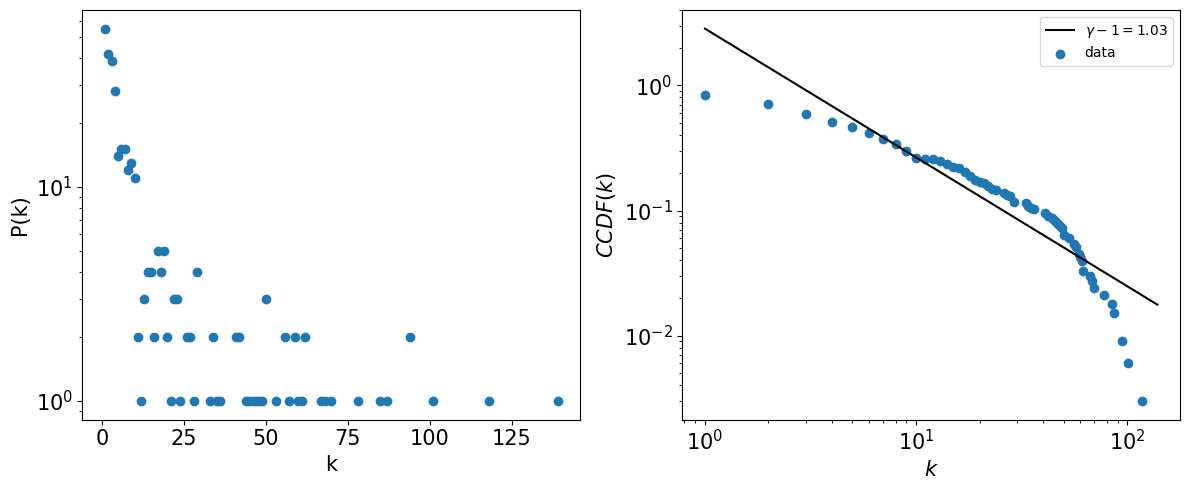

In [56]:
degree_sequence=[G.degree(node) for node in G.nodes()]
from collections import Counter

degree_counts = Counter(degree_sequence)
min_degree=min(degree_sequence)
max_degree=max(degree_sequence)

degree = list(range(min_degree, max_degree + 1))
degree_count = [degree_counts.get(k, 0) for k in degree]

degree=[degree[i] for i in range(len(degree)) if degree_count[i]!=0]
degree_count=[degree_count[i] for i in range(len(degree_count)) if degree_count[i]!=0]

cdf=np.cumsum(degree_count)/G.number_of_nodes() ### Get the cumulative sum of the distribution (without normalized)
ccdf=np.ones(len(cdf))-cdf #### Get the CCDF 

log_degree_fit=[np.log(degree[i]) for i in range(len(degree))][:-1] ## Last point should be excluded as 0 in logarithmic scale is not finite
log_ccdf_fit=np.log(ccdf)[:-1]

m,b = np.polyfit(log_degree_fit, log_ccdf_fit, 1) 

theoretical=[np.exp(b)*k**m for k in degree]

fig,ax=plt.subplots(1,2,figsize=(12,5))


ax[0].scatter(degree,degree_count)
ax[0].set_yscale('log')
ax[0].set_ylabel('P(k)',fontsize=15)
ax[0].set_xlabel('k',fontsize=15)
ax[0].tick_params(which='major',axis='both',labelsize=15)


ax[1].plot(degree, theoretical,color='black',label=r'$\gamma-1=%.2f$'%(-m))
ax[1].scatter(degree, ccdf,label='data')

ax[1].set_yscale('log')
ax[1].set_xscale('log')

ax[1].set_xlabel('$k$',fontsize=15)
ax[1].set_ylabel('$CCDF(k)$',fontsize=15)

ax[1].tick_params(which='major',axis='both',labelsize=15)

ax[1].legend()

fig.tight_layout()